In [1]:
import pandas as pd
import numpy as np

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [10]:
df = pd.read_csv('/content/drive/MyDrive/Corona_NLP_test.csv')
df['OriginalTweet'] = df['OriginalTweet'].str.lower()
df['OriginalTweet'] = df['OriginalTweet'].str.strip().str.replace(r'\s+', ' ', regex=True)
df['OriginalTweet'] = df['OriginalTweet'].str.replace(r'[^a-zA-Z0-9\s]', '', regex=True)
df.head(10)

,UserName,ScreenName,Location,TweetAt,OriginalTweet,Sentiment
0,1,44953,NYC,02-03-2020,trending new yorkers encounter empty supermark...,Extremely Negative
1,2,44954,"Seattle, WA",02-03-2020,when i couldnt find hand sanitizer at fred mey...,Positive
2,3,44955,NaN,02-03-2020,find out how you can protect yourself and love...,Extremely Positive
3,4,44956,Chicagoland,02-03-2020,panic buying hits newyork city as anxious shop...,Negative
4,5,44957,"Melbourne, Victoria",03-03-2020,toiletpaper dunnypaper coronavirus coronavirus...,Neutral
5,6,44958,Los Angeles,03-03-2020,do you remember the last time you paid 299 a g...,Neutral
6,7,44959,NaN,03-03-2020,voting in the age of coronavirus hand sanitiz...,Positive
7,8,44960,"Geneva, Switzerland",03-03-2020,drtedros we cant stop covid19 without protecti...,Neutral
8,9,44961,NaN,04-03-2020,hi twitter i am a pharmacist i sell hand sanit...,Extremely Negative
9,10,44962,"Dublin, Ireland",04-03-2020,anyone been in a supermarket over the last few...,Extremely Positive


In [12]:
print(df.columns)

Index(['User Name', 'Screen Name', 'Location', 'Tweet At', 'Original Tweet',
       'Sentiment'],
      dtype='object')


In [11]:
import re

def split_camel_case(col_name):
    # Insert a space before any uppercase letter that is not at the start of the string
    return re.sub(r'(?<!^)(?=[A-Z])', ' ', col_name)

# Apply the function to all column names
df.columns = [split_camel_case(col) for col in df.columns]

df.head(10)

,User Name,Screen Name,Location,Tweet At,Original Tweet,Sentiment
0,1,44953,NYC,02-03-2020,trending new yorkers encounter empty supermark...,Extremely Negative
1,2,44954,"Seattle, WA",02-03-2020,when i couldnt find hand sanitizer at fred mey...,Positive
2,3,44955,NaN,02-03-2020,find out how you can protect yourself and love...,Extremely Positive
3,4,44956,Chicagoland,02-03-2020,panic buying hits newyork city as anxious shop...,Negative
4,5,44957,"Melbourne, Victoria",03-03-2020,toiletpaper dunnypaper coronavirus coronavirus...,Neutral
5,6,44958,Los Angeles,03-03-2020,do you remember the last time you paid 299 a g...,Neutral
6,7,44959,NaN,03-03-2020,voting in the age of coronavirus hand sanitiz...,Positive
7,8,44960,"Geneva, Switzerland",03-03-2020,drtedros we cant stop covid19 without protecti...,Neutral
8,9,44961,NaN,04-03-2020,hi twitter i am a pharmacist i sell hand sanit...,Extremely Negative
9,10,44962,"Dublin, Ireland",04-03-2020,anyone been in a supermarket over the last few...,Extremely Positive


Now, let's tokenize the `Original Tweet` column into words.

In [4]:
df.shape

(3798, 6)

In [21]:
import nltk
from nltk.tokenize import word_tokenize
from collections import defaultdict, Counter

# Download necessary NLTK data
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

Now, let's tokenize the `Original Tweet` column into words.

In [22]:
df['tokenized_tweet'] = df['Original Tweet'].apply(word_tokenize)
display(df[['Original Tweet', 'tokenized_tweet']].head())

,Original Tweet,tokenized_tweet
0,trending new yorkers encounter empty supermark...,"[trending, new, yorkers, encounter, empty, sup..."
1,when i couldnt find hand sanitizer at fred mey...,"[when, i, couldnt, find, hand, sanitizer, at, ..."
2,find out how you can protect yourself and love...,"[find, out, how, you, can, protect, yourself, ..."
3,panic buying hits newyork city as anxious shop...,"[panic, buying, hits, newyork, city, as, anxio..."
4,toiletpaper dunnypaper coronavirus coronavirus...,"[toiletpaper, dunnypaper, coronavirus, coronav..."


Next, we'll build N-gram models (bigrams and trigrams) to capture word sequences and their frequencies. This will allow us to predict the next word based on previous words.

In [23]:
from nltk.util import ngrams

# Prepare lists for all words, bigrams, and trigrams
all_words = []
for tokens in df['tokenized_tweet']:
    all_words.extend(tokens)

bigrams = list(ngrams(all_words, 2))
trigrams = list(ngrams(all_words, 3))

# Calculate frequencies
bigram_counts = Counter(bigrams)
trigram_counts = Counter(trigrams)

print(f"Total unique bigrams: {len(bigram_counts)}")
print(f"Total unique trigrams: {len(trigram_counts)}")

Total unique bigrams: 70027
Total unique trigrams: 106708


Finally, we can create a simple prediction function. This function will take a word or a sequence of words as input and suggest the most likely next word based on our bigram and trigram frequencies.

Now, let's implement algorithms for spelling error correction (autocorrect).

### 1. Define and Measure Performance Metrics for Autocorrect

For autocorrect, common performance metrics include:

*   **Accuracy:** The percentage of words in a test set (misspelled or not) that are correctly identified or corrected.
*   **Recall (of misspelled words):** The percentage of actual misspelled words that the autocorrect system successfully corrected.
*   **Precision (of corrections):** The percentage of suggested corrections that are actually correct.

To measure these, we need a test dataset with words and their correct spellings. Let's create a small synthetic one to demonstrate.

In [26]:
test_words = [
    ('coronaviurs', 'coronavirus'),
    ('supermaket', 'supermarket'),
    ('positve', 'positive'),
    ('empt', 'empty'),
    ('supermarket', 'supermarket'), # Already correct
    ('pandmic', 'pandemic'),
    ('shoper', 'shopper'),
    ('locaton', 'location'),
    ('tweat', 'tweet'),
    ('flue', 'flu')
]

def evaluate_autocorrect(test_set, correct_func):
    total_words = len(test_set)
    correct_predictions = 0
    misspelled_corrected = 0
    total_misspelled = 0
    total_corrections_made = 0
    correct_corrections_made = 0

    print("\n--- Autocorrect Evaluation ---")
    for original_word, true_correction in test_set:
        predicted_correction = correct_func(original_word)
        is_misspelled = (original_word != true_correction)

        if predicted_correction == true_correction:
            correct_predictions += 1
            if is_misspelled:
                misspelled_corrected += 1

        if original_word != predicted_correction: # A correction was attempted/made
            total_corrections_made += 1
            if predicted_correction == true_correction:
                correct_corrections_made += 1

        if is_misspelled:
            total_misspelled += 1

        print(f"Original: '{original_word}' -> Predicted: '{predicted_correction}' (True: '{true_correction}')")

    accuracy = (correct_predictions / total_words) * 100
    recall = (misspelled_corrected / total_misspelled) * 100 if total_misspelled > 0 else 0
    precision = (correct_corrections_made / total_corrections_made) * 100 if total_corrections_made > 0 else 0

    print("\n--- Results ---")
    print(f"Total words tested: {total_words}")
    print(f"Correct predictions: {correct_predictions}")
    print(f"Accuracy: {accuracy:.2f}%")
    print(f"Misspelled words corrected: {misspelled_corrected} out of {total_misspelled}")
    print(f"Recall (of misspelled words): {recall:.2f}%")
    print(f"Corrections made: {total_corrections_made}")
    print(f"Correct corrections: {correct_corrections_made}")
    print(f"Precision (of corrections): {precision:.2f}%")

evaluate_autocorrect(test_words, correct_word)



--- Autocorrect Evaluation ---
Original: 'coronaviurs' -> Predicted: 'coronavirus' (True: 'coronavirus')
Original: 'supermaket' -> Predicted: 'supermarket' (True: 'supermarket')
Original: 'positve' -> Predicted: 'positive' (True: 'positive')
Original: 'empt' -> Predicted: 'empty' (True: 'empty')
Original: 'supermarket' -> Predicted: 'supermarket' (True: 'supermarket')
Original: 'pandmic' -> Predicted: 'pandemic' (True: 'pandemic')
Original: 'shoper' -> Predicted: 'shopper' (True: 'shopper')
Original: 'locaton' -> Predicted: 'location' (True: 'location')
Original: 'tweat' -> Predicted: 'tweet' (True: 'tweet')
Original: 'flue' -> Predicted: 'flu' (True: 'flu')

--- Results ---
Total words tested: 10
Correct predictions: 10
Accuracy: 100.00%
Misspelled words corrected: 9 out of 9
Recall (of misspelled words): 100.00%
Corrections made: 9
Correct corrections: 9
Precision (of corrections): 100.00%


### Defining Metrics for Autocomplete/Next Word Prediction

For autocomplete, metrics are often more complex due to the probabilistic nature of predictions:

*   **Perplexity:** A measure of how well a probability model predicts a sample. Lower perplexity indicates a better model. This is calculated over a large corpus of text.
*   **Top-N Accuracy:** If the true next word is among the top N predictions made by the model, it's considered a success. This is often evaluated on a held-out test set.
*   **Mean Reciprocal Rank (MRR):** Measures the effectiveness of a system that returns a ranked list of possible responses to a query. If the correct prediction is ranked higher, MRR will be higher.

Evaluating these metrics typically requires a large test corpus where the true next words are known. Given our current setup, generating such a corpus for a robust evaluation is beyond the scope of a quick demonstration, but these are the metrics you would consider for a full-scale evaluation.

### 2. Assess User Experience and 3. Evaluate Different Models

These two tasks are outside the direct capabilities of this environment as they require real-world interaction and extensive model development beyond simple N-grams:

*   **User Experience:** This would involve deploying the autocomplete/autocorrect functionality into an application, gathering user feedback through surveys, usability testing, and analyzing usage patterns. We can design the framework for such an assessment, but cannot execute it here.
*   **Algorithm Comparison:** To evaluate different models (e.g., comparing N-grams to Transformer-based models), you would need to implement or integrate those models, train them on your data, and then compare their performance using the metrics defined above, along with computational efficiency (speed, memory usage). This is a significant research and development effort.


### 4. Use Tools for Data Visualization

We've already done some basic visualization by examining word frequencies and n-gram counts, which are fundamental to these models. For further visualization related to model performance, once we had a proper evaluation framework, we could:

*   **Plot accuracy/recall/precision over different parameters or datasets.**
*   **Visualize the distribution of predicted words** to see if they align with expectations.
*   **Create confusion matrices** for autocorrect to see which misspellings are corrected to what.

Here's an example of visualizing the most common trigrams, which is part of our model's foundation:

/tmp/ipykernel_7663/1087229453.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=trigram_values, y=trigram_labels, palette='viridis')


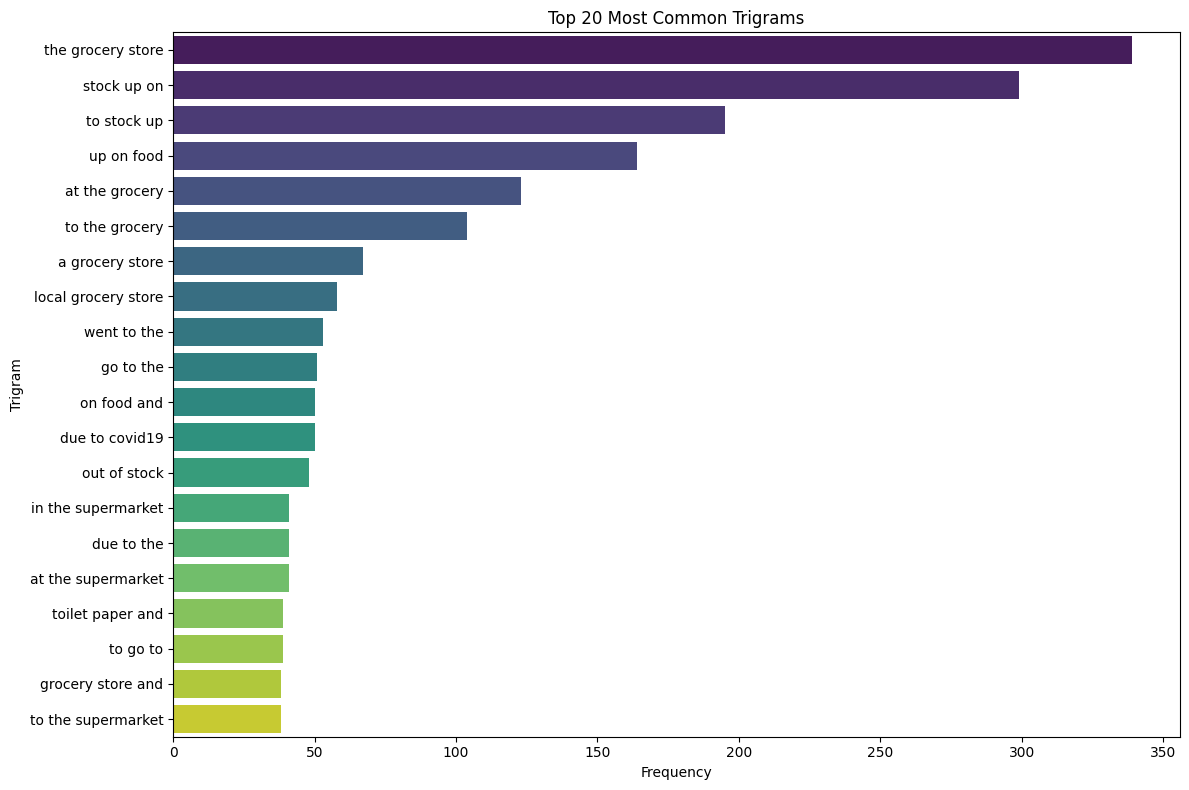

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get the 20 most common trigrams
most_common_trigrams = trigram_counts.most_common(20)

# Prepare data for plotting
trigram_labels = [' '.join(ngram) for ngram, count in most_common_trigrams]
trigram_values = [count for ngram, count in most_common_trigrams]

plt.figure(figsize=(12, 8))
sns.barplot(x=trigram_values, y=trigram_labels, palette='viridis')
plt.title('Top 20 Most Common Trigrams')
plt.xlabel('Frequency')
plt.ylabel('Trigram')
plt.tight_layout()
plt.show()


This visualization helps us understand the most frequent three-word sequences in our dataset, which directly informs our trigram-based autocomplete model. Would you like to explore specific visualizations for the autocorrect or autocomplete evaluation results, or would you like to move on to another aspect?

In [25]:
from collections import Counter

# Assuming all_words and trigram_counts/bigram_counts are already defined from previous steps
# If not, ensure they are generated before running this cell.

# Build a vocabulary set for quick lookups
vocabulary = set(all_words)

# Calculate word frequencies for ranking corrections
word_counts = Counter(all_words)

def edits1(word):
    """All edits that are one edit away from `word`."""
    letters    = 'abcdefghijklmnopqrstuvwxyz'
    splits     = [(word[:i], word[i:])    for i in range(len(word) + 1)]
    deletes    = [L + R[1:]               for L, R in splits if R]
    transposes = [L + R[1] + R[0] + R[2:] for L, R in splits if len(R)>1]
    replaces   = [L + c + R[1:]           for L, R in splits if R for c in letters]
    inserts    = [L + c + R               for L, R in splits for c in letters]
    return set(deletes + transposes + replaces + inserts)

def known(words):
    """The subset of `words` that appear in the `vocabulary`."""
    return set(w for w in words if w in vocabulary)

def candidates(word):
    """Generate possible spelling corrections for word."""
    return (known([word]) or known(edits1(word)) or known(edits1(edits2(word))) or [word])

def edits2(word):
    """All edits that are two edits away from `word`."""
    return (e2 for e1 in edits1(word) for e2 in edits1(e1))

def correct_word(word):
    """Find the best spelling correction for a word based on frequency."""
    # Rank candidates by frequency, then alphabetically
    return max(candidates(word.lower()), key=lambda w: (word_counts[w], w))

# Example Usage:
print("Correction for 'coronaviurs':", correct_word('coronaviurs'))
print("Correction for 'supermaket':", correct_word('supermaket'))
print("Correction for 'positve':", correct_word('positve'))
print("Correction for 'empt':", correct_word('empt'))
print("Correction for 'supermarket':", correct_word('supermarket')) # Already correct


Correction for 'coronaviurs': coronavirus
Correction for 'supermaket': supermarket
Correction for 'positve': positive
Correction for 'empt': empty
Correction for 'supermarket': supermarket


In [24]:
def predict_next_word(text, n_gram_counts=trigram_counts, prev_n_gram_counts=bigram_counts, n=3):
    # Tokenize the input text
    tokens = word_tokenize(text.lower())

    # Use the last (n-1) tokens as context
    context = tuple(tokens[-(n-1):])

    # Find all n-grams that start with the context
    possible_next_words = defaultdict(lambda: 0.0)

    for ngram, count in n_gram_counts.items():
        if ngram[:-1] == context:
            possible_next_words[ngram[-1]] = count

    if not possible_next_words:
        # If no (n)-gram found, fall back to (n-1)-grams (e.g., bigrams if n=3)
        if n > 2:
            return predict_next_word(text, n_gram_counts=prev_n_gram_counts, n=n-1)
        else:
            # If even bigrams don't match, suggest most common unigrams
            most_common_words = Counter(all_words).most_common(5)
            return [word for word, count in most_common_words]

    # Sort by frequency and return the top predictions
    sorted_predictions = sorted(possible_next_words.items(), key=lambda item: item[1], reverse=True)
    return [word for word, count in sorted_predictions[:5]]

# Example usage:
print("Prediction for 'empty supermarkets':", predict_next_word('empty supermarkets'))
print("Prediction for 'find out how':", predict_next_word('find out how'))
print("Prediction for 'the':", predict_next_word('the', n_gram_counts=bigram_counts, n=2))
print("Prediction for 'coronavirus':", predict_next_word('coronavirus', n_gram_counts=bigram_counts, n=2))

Prediction for 'empty supermarkets': ['are', 'is', 'and', 'covid19', 'who']
Prediction for 'find out how': ['coronavirus', 'you']
Prediction for 'the': ['grocery', 'coronavirus', 'supermarket', 'covid19', 'store']
Prediction for 'coronavirus': ['covid19', 'is', 'i', 'pandemic', 'and']
